In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
classification_report, confusion_matrix, ConfusionMatrixDisplay)


In [40]:
# 2.2 Exploratory data analysis and Data preprocessing techniques
# Import dataset
data = pd.read_csv("dirty_cafe_sales.csv", header=0, sep=",")
print("Data shape: ", data.shape)
print("\nTop 5 rows: ", data.head())
print("\nData types: ", data.dtypes)

# Convert numerical columns to numeric
data["Quantity"] = pd.to_numeric(data["Quantity"], errors="coerce")
data["Price Per Unit"] = pd.to_numeric(data["Price Per Unit"], errors="coerce")
data["Total Spent"] = pd.to_numeric(data["Total Spent"], errors="coerce")

# Convert transaction date to datetime
data["Transaction Date"] = pd.to_datetime(data["Transaction Date"], errors="coerce")

# Calculate missing percentage
missing_percent = (data.isnull().sum() / len(data)) * 100
missing_table = pd.DataFrame({
    'Feature': missing_percent.index,
    'Missing (%)': missing_percent.values
})
missing_table = missing_table.sort_values('Missing (%)', ascending=False)
missing_table = missing_table.reset_index(drop=True)
# Printing the table
print("\nMising Values Percentage:")
print(missing_table.to_string(index=False))


Data shape:  (10000, 8)

Top 5 rows:    Transaction ID    Item Quantity Price Per Unit Total Spent  Payment Method  \
0    TXN_1961373  Coffee        2            2.0         4.0     Credit Card   
1    TXN_4977031    Cake        4            3.0        12.0            Cash   
2    TXN_4271903  Cookie        4            1.0       ERROR     Credit Card   
3    TXN_7034554   Salad        2            5.0        10.0         UNKNOWN   
4    TXN_3160411  Coffee        2            2.0         4.0  Digital Wallet   

   Location Transaction Date  
0  Takeaway       2023-09-08  
1  In-store       2023-05-16  
2  In-store       2023-07-19  
3   UNKNOWN       2023-04-27  
4  In-store       2023-06-11  

Data types:  Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

Mising Values Percentage:
         Feature  Missing (%)
        Location  

In [41]:
# Recover missing Total Spent where possible
data.loc[
    data["Total Spent"].isna() &
    data["Quantity"].notna() &
    data["Price Per Unit"].notna(), "Total Spent"
] = data["Quantity"] * data["Price Per Unit"]

# Drop rows we can't recover
initial_rows = len(data)
data.dropna(subset=["Quantity", "Price Per Unit", "Total Spent", "Transaction Date"], inplace=True)

# Replace error placeholders
data.replace(["error", "unknown", "Error", "Unknown", 'ERROR', 'UNKNOWN'], np.nan, inplace=True)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9993,TXN_4766549,Smoothie,2.0,4.0,8.0,Cash,NaN,2023-10-20
9994,TXN_7851634,NaN,4.0,4.0,16.0,NaN,NaN,2023-01-08
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,NaN,2023-08-30
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02


In [42]:
# Extract date features
data["Day_of_Week"] = data["Transaction Date"].dt.dayofweek
data["Month"] = data["Transaction Date"].dt.month
data["Is_Weekend"] = (data["Day_of_Week"] >= 5).astype(int)



Class distribution:
  Juice           :  1020 (13.1%)
  Coffee          :  1012 (13.0%)
  Cake            :   989 (12.7%)
  Salad           :   985 (12.7%)
  Sandwich        :   969 (12.5%)
  Smoothie        :   951 (12.2%)
  Cookie          :   929 (12.0%)
  Tea             :   918 (11.8%)


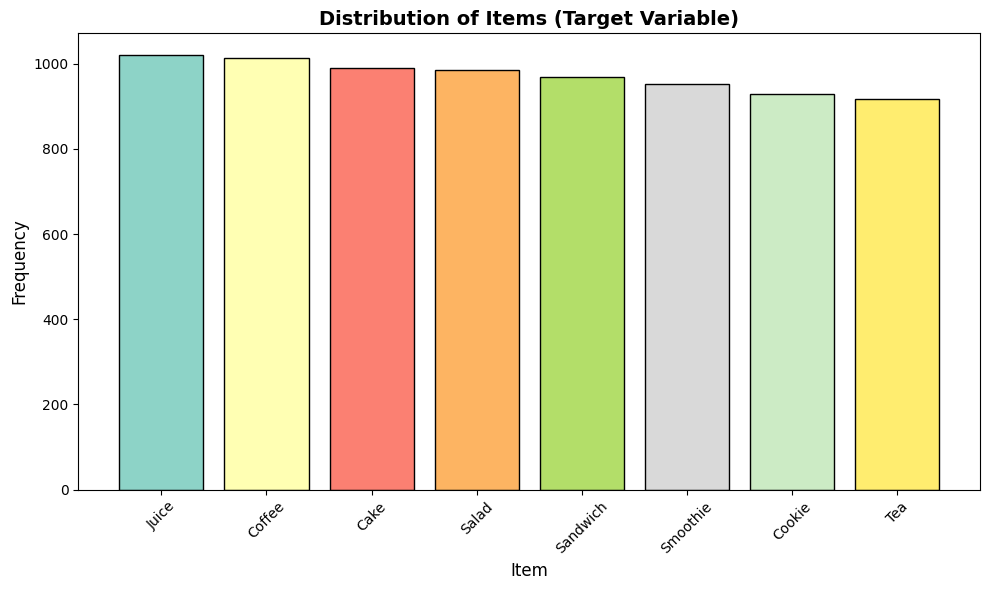

In [43]:
# Define valid items
valid_items = ['Coffee', 'Tea', 'Juice', 'Smoothie', 'Cake', 'Cookie', 'Sandwich', 'Salad']
data = data[data["Item"].isin(valid_items)]

# Fill any remaining missing items with mode
data["Item"] = data["Item"].fillna(data["Item"].mode()[0] if not data["Item"].mode().empty else "Coffee")

print("\nClass distribution:")
item_counts = data["Item"].value_counts()
for item, count in item_counts.items():
    print(f"  {item:15s} : {count:5d} ({count/len(data)*100:.1f}%)")

# Visualize class distribution
plt.figure(figsize=(10, 6))
colors = plt.cm.Set3(np.linspace(0, 1, len(item_counts)))
plt.bar(item_counts.index, item_counts.values, color=colors, edgecolor='black')
plt.title('Distribution of Items (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Item', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
# Handle missing categorical values
data["Payment Method"] = data["Payment Method"].fillna("Missing")
data["Location"] = data["Location"].fillna("Unknown")

# One-hot encoding for Payment Method
payment_dummies = pd.get_dummies(data["Payment Method"], prefix="payment")
data = pd.concat([data, payment_dummies], axis=1)

# One-hot encoding for Location
location_dummies = pd.get_dummies(data["Location"], prefix="location")
data = pd.concat([data, location_dummies], axis=1)

print("One-hot encoded: Payment Method and Location")
print(data)

One-hot encoded: Payment Method and Location
     Transaction ID      Item  Quantity  Price Per Unit  Total Spent  \
0       TXN_1961373    Coffee       2.0             2.0          4.0   
1       TXN_4977031      Cake       4.0             3.0         12.0   
2       TXN_4271903    Cookie       4.0             1.0          4.0   
3       TXN_7034554     Salad       2.0             5.0         10.0   
4       TXN_3160411    Coffee       2.0             2.0          4.0   
...             ...       ...       ...             ...          ...   
9992    TXN_2739140  Smoothie       4.0             4.0         16.0   
9993    TXN_4766549  Smoothie       2.0             4.0          8.0   
9995    TXN_7672686    Coffee       2.0             2.0          4.0   
9997    TXN_5255387    Coffee       4.0             2.0          8.0   
9999    TXN_6170729  Sandwich       3.0             4.0         12.0   

      Payment Method  Location Transaction Date  Day_of_Week  Month  \
0        Credit Car

In [45]:
# Dropping original columns that are not needed for modeling
cols_to_drop = [
    'Transaction ID', 'Transaction Date', 'Location', 'Payment Method',
    'Spent_Category', 'Quantity_Category'
]

data = data.drop(columns=[col for col in cols_to_drop if col in data.columns])

print(f"Final column count: {data.shape[1] - 1} (excluding target)")

# Display final features
feature_cols = [col for col in data.columns if col != 'Item']
print(f"\nFeatures ({len(feature_cols)} columns):")
for i, col in enumerate(feature_cols[:15]):
    print(f"  {i+1:2d}. {col}")
if len(feature_cols) > 15:
    print(f"  ... and {len(feature_cols)-15} more")

Final column count: 13 (excluding target)

Features (13 columns):
   1. Quantity
   2. Price Per Unit
   3. Total Spent
   4. Day_of_Week
   5. Month
   6. Is_Weekend
   7. payment_Cash
   8. payment_Credit Card
   9. payment_Digital Wallet
  10. payment_Missing
  11. location_In-store
  12. location_Takeaway
  13. location_Unknown


Target encoding mapping:
  Cake            → 0
  Coffee          → 1
  Cookie          → 2
  Juice           → 3
  Salad           → 4
  Sandwich        → 5
  Smoothie        → 6
  Tea             → 7

Training set: 6218 rows (80.0%)
Testing set:  1555 rows (20.0%)
Features were scaled using StandardScaler


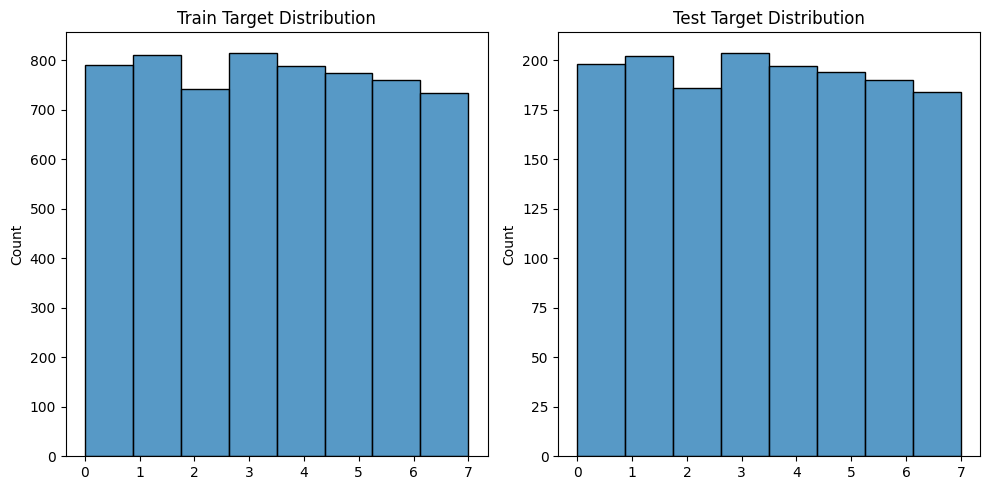

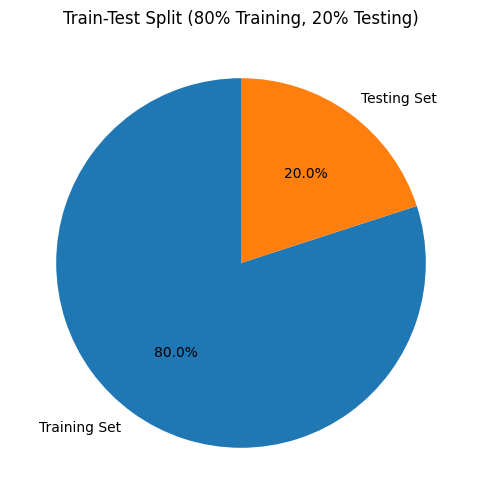

In [46]:
# Train-test split
X = data.drop(columns=['Item'])
y = data['Item']

# Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"Target encoding mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {class_name:15s} → {i}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTraining set: {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set:  {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features were scaled using StandardScaler")

# Train vs Test distribution histograms
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.histplot(y_train, bins=len(set(y_encoded)))
plt.title("Train Target Distribution")

plt.subplot(1,2,2)
sns.histplot(y_test, bins=len(set(y_encoded)))
plt.title("Test Target Distribution")
plt.tight_layout()
plt.show()

# Train vs Test Split Pie Chart
labels = ['Training Set', 'Testing Set']
sizes = [len(X_train), len(X_test)]

plt.figure(figsize=(6,6))
plt.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=90
)

plt.title("Train-Test Split (80% Training, 20% Testing)")
plt.show()


LOGISTIC REGRESSION PERFORMANCE:

Accuracy: 0.7460

Precision: 0.7457

Recall: 0.7460

F1-Score: 0.7441

RANDOM FOREST PERFORMANCE:

Accuracy: 0.7588

Precision: 0.7589

Recall: 0.7588

F1-Score: 0.7588


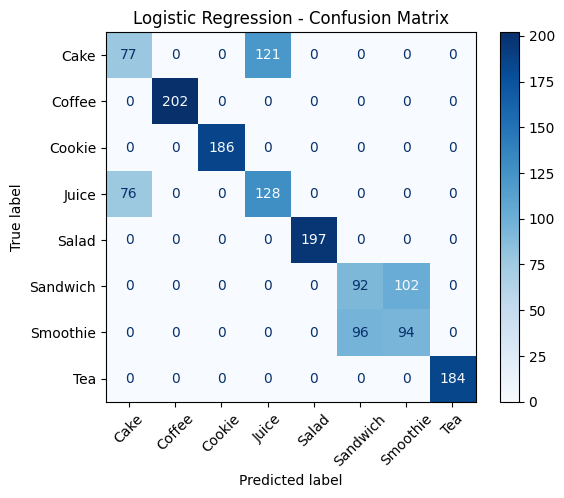

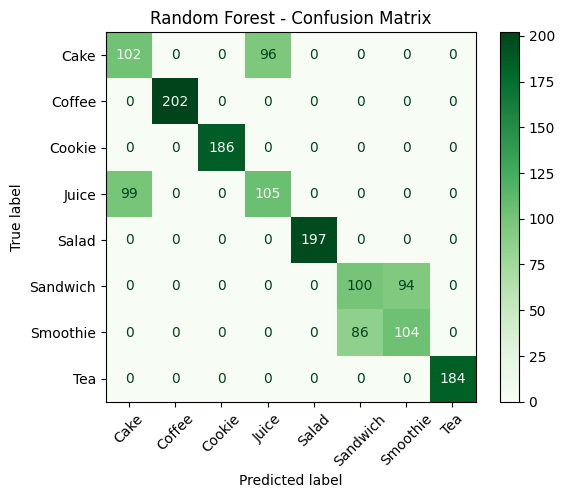

In [47]:
# 2.3 Machine learning models
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = lr.predict(X_test_scaled)

# Calculate metrics
acc_lr = accuracy_score(y_test, y_pred_lr)
pre_lr = precision_score(y_test, y_pred_lr, average='weighted')
rec_lr = recall_score(y_test, y_pred_lr, average='weighted')
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf.predict(X_test_scaled)

# Calculate metrics
acc_rf = accuracy_score(y_test, y_pred_rf)
pre_rf = precision_score(y_test, y_pred_rf, average='weighted')
rec_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')


# 2.4 Performance evaluation and comparison
print("\nLOGISTIC REGRESSION PERFORMANCE:")
print(f"\nAccuracy: {acc_lr:.4f}")
print(f"\nPrecision: {pre_lr:.4f}")
print(f"\nRecall: {rec_lr:.4f}")
print(f"\nF1-Score: {f1_lr:.4f}")

print("\nRANDOM FOREST PERFORMANCE:")
print(f"\nAccuracy: {acc_rf:.4f}")
print(f"\nPrecision: {pre_rf:.4f}") 
print(f"\nRecall: {rec_rf:.4f}")
print(f"\nF1-Score: {f1_rf:.4f}")

# Logistic Regression Vizualization
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=label_encoder.classes_)
disp_lr.plot(cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

# Random Forest Vizualization
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=label_encoder.classes_)
disp_rf.plot(cmap='Greens')
plt.title("Random Forest - Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

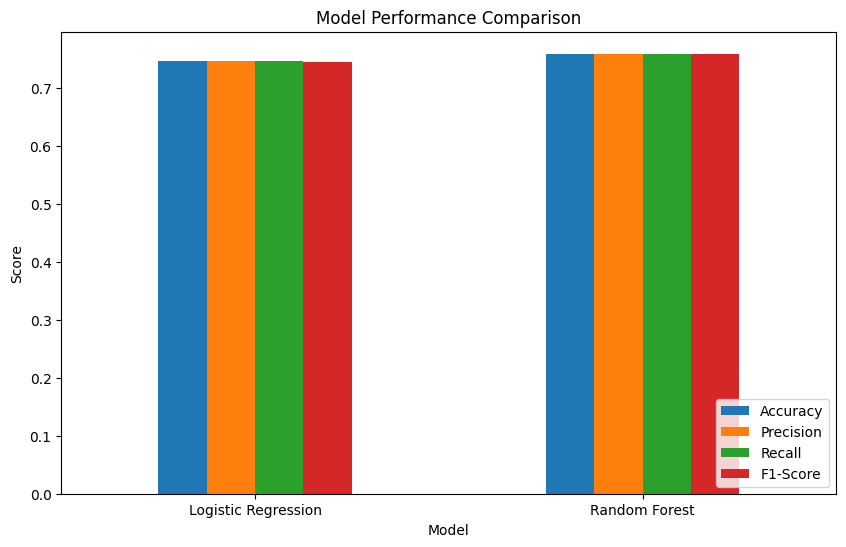

In [48]:
# Performance comparison bar chart
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [acc_lr, acc_rf],
    "Precision": [pre_lr, pre_rf],
    "Recall": [rec_lr, rec_rf],
    "F1-Score": [f1_lr, f1_rf]
})

results.set_index("Model").plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

In [49]:
# Classification report 
print("Logistic Regression Report:")
print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))

print("\nRandom Forest Report:")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

Logistic Regression Report:
              precision    recall  f1-score   support

        Cake       0.50      0.39      0.44       198
      Coffee       1.00      1.00      1.00       202
      Cookie       1.00      1.00      1.00       186
       Juice       0.51      0.63      0.57       204
       Salad       1.00      1.00      1.00       197
    Sandwich       0.49      0.47      0.48       194
    Smoothie       0.48      0.49      0.49       190
         Tea       1.00      1.00      1.00       184

    accuracy                           0.75      1555
   macro avg       0.75      0.75      0.75      1555
weighted avg       0.75      0.75      0.74      1555


Random Forest Report:
              precision    recall  f1-score   support

        Cake       0.51      0.52      0.51       198
      Coffee       1.00      1.00      1.00       202
      Cookie       1.00      1.00      1.00       186
       Juice       0.52      0.51      0.52       204
       Salad       1.00    

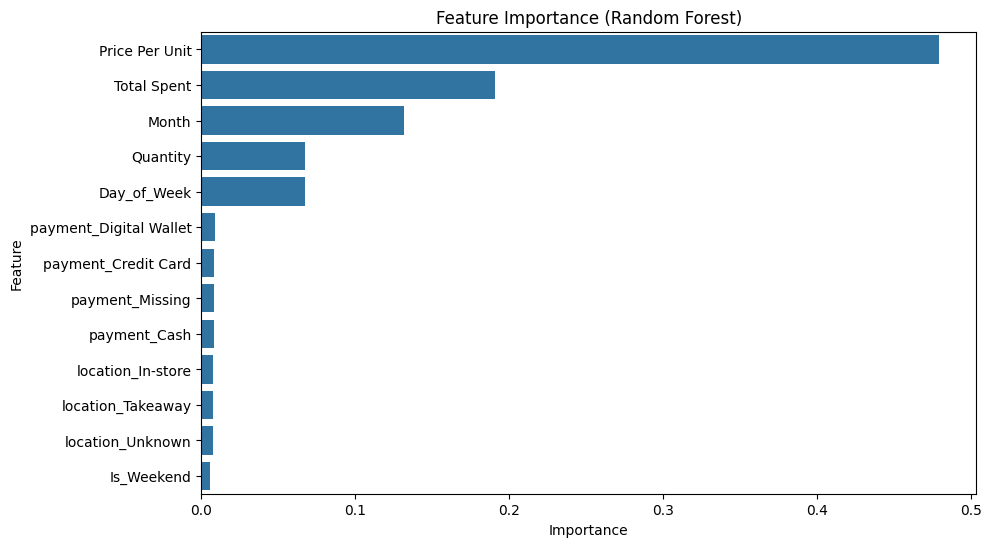

In [50]:
# Feature importance for Random Forest

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance)
plt.title("Feature Importance (Random Forest)")
plt.show()